# 10 · The real Brain-Score: CLIP predicts IT neural responses

CLIP ViT-B/32, from images alone, predicting held-out MajajHong2015 IT neural
responses (168 recording sites, 3200 images). Scoring ran on EC2 with real
neural data and cross-validated PLS; this notebook replots the saved
predictions. The scoring code is at the end.

**Pearson r** is the correlation between predicted and measured responses across
images: `r = 0` is chance (a shuffled image->response pairing), `r = 1` is
perfect. All numbers here are raw, unceiled per-site correlations.

## The best-predicted IT site

Of the 168 IT sites we plot the **single best-predicted one** (neuroid 103,
chosen as the argmax over sites). This is a best case, not a typical site -- the
full distribution is in the next figure. Each point is one image: its measured
held-out response vs CLIP's prediction.

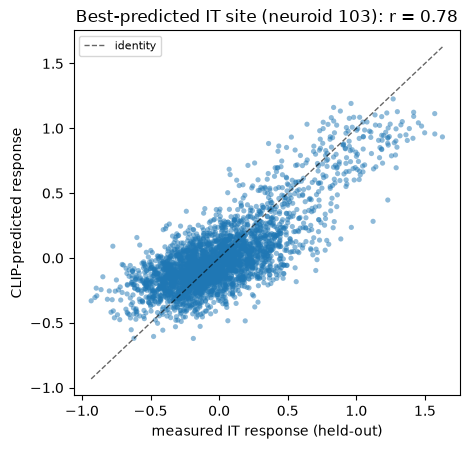

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Precomputed CLIP->IT results from the real MajajHong benchmark (measured vs predicted, held-out).
d = np.load('assets/clip_majajhong_it.npz')
y, p = d['measured'], d['predicted']
r = float(d['best_r']); median_r = float(d['median_r']); best = int(d['best_neuroid'])

# permutation null: break the image<->response pairing, recompute r (200x)
rng = np.random.RandomState(0)
null = np.array([np.corrcoef(p, rng.permutation(y))[0, 1] for _ in range(200)])
null_hi = float(np.percentile(np.abs(null), 95))

# Scatter measured vs CLIP-predicted response for the single best-predicted IT site.
fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.scatter(y, p, s=14, alpha=0.5, edgecolor='none')
lo, hi = float(np.min([y, p])), float(np.max([y, p]))
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6, label='identity')
ax.set_xlabel('measured IT response (held-out)')
ax.set_ylabel('CLIP-predicted response')
ax.set_title(f'Best-predicted IT site (neuroid {best}): r = {r:.2f}')
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout(); plt.show()

Shuffling the image->response pairing gives `r` near zero (95% of shuffles below the value printed below), so `r = 0.78` at this site is far above chance.

In [2]:
# Chance ceiling on |r| when the image->response pairing is randomised.
print(f'shuffled-pairing null: |r| < {null_hi:.3f} for 95% of 200 permutations')

shuffled-pairing null: |r| < 0.032 for 95% of 200 permutations


## Across all 168 IT sites

Per-site predictivity. The shaded band is the shuffled-pairing null (chance);
the dashed line is the median across sites. The benchmark's own metric reports
the same median.

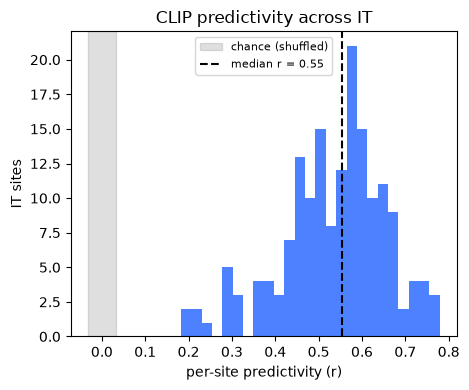

median r = 0.555 across 168 IT sites; best site r = 0.779; chance |r| < 0.032


In [3]:
# Predictivity across all IT sites, with the chance band and median marked.
rs = d['per_neuroid_r']
fig, ax = plt.subplots(figsize=(4.8, 4.0))
ax.axvspan(-null_hi, null_hi, color='gray', alpha=0.25, label='chance (shuffled)')
ax.hist(rs[~np.isnan(rs)], bins=25, color='#2f6bff', alpha=0.85)
ax.axvline(median_r, c='k', ls='--', label=f'median r = {median_r:.2f}')
ax.set_xlabel('per-site predictivity (r)'); ax.set_ylabel('IT sites')
ax.set_title('CLIP predictivity across IT'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f'median r = {median_r:.3f} across {len(rs)} IT sites; '
      f'best site r = {r:.3f}; chance |r| < {null_hi:.3f}')

Every one of the 168 sites clears the chance band -- CLIP's image features
carry real information about IT responses, and the median site is predicted at
`r = 0.55`.

## How it was produced (EC2)

Real neural data plus PLS is heavier than a laptop path, so this ran on EC2. The
authoritative score comes straight from the benchmark's own metric; the scatter
just reproduces its cross-validation to keep the held-out predictions.

```python
import numpy as np
import brainscore
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import StratifiedShuffleSplit

model = brainscore.load_model('clip-vit-b-32')
bench = brainscore.load_benchmark('MajajHong2015public.IT-pls-unified')
neural = bench._assembly                       # (3200 images, 168 IT sites)

model.start_recording('IT')
feats = model.process(neural.stimulus_set)     # (3200, 38400)
score = bench._similarity_metric(feats, neural)  # authoritative benchmark score

# reproduce the CV to capture held-out predictions for the scatter:
X = np.asarray(feats.values); Y = np.asarray(neural.values)
obj = np.asarray(neural['object_name'].values)                 # stratify by object
sss = StratifiedShuffleSplit(n_splits=10, train_size=0.9, random_state=0)
pred = np.full_like(Y, np.nan); cnt = np.zeros(len(Y))
for tr, te in sss.split(X, obj):
    pls = PLSRegression(n_components=25, scale=False).fit(X[tr], Y[tr])
    pred[te] += pls.predict(X[te]); cnt[te] += 1
pred /= cnt[:, None]
per_site_r = [pearsonr(pred[:, j], Y[:, j])[0] for j in range(Y.shape[1])]
```

The full score through the public surface is `brainscore.score('clip-vit-b-32',
'MajajHong2015public.IT-pls-unified')`. For a laptop-safe look at model
representations without neural data, see notebook 03.